In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import spacy
from collections import Counter
from wordcloud import WordCloud
from transformers import pipeline


In [ ]:
file_path = '/content/final_combined_file.csv'
df = pd.read_csv(file_path)

In [ ]:
print(df.head())
print(df.info())

                                           headlines  \
0  Nirmala Sitharaman to equal Morarji Desai’s re...   
1  ‘Will densify network, want to be at least no....   
2  Air India group to induct an aircraft every si...   
3  Red Sea woes: Exporters seek increased credit ...   
4  Air India group to induct a plane every 6 days...   

                                         description  \
0  With the presentation of the interim budget on...   
1  'In terms of market share, we aim to double it...   
2  Air India currently has 117 operational aircra...   
3  Rising attacks forced shippers to consider the...   
4  Apart from fleet expansion, 2024 will also see...   

                                             content  \
0  Sitharaman, the first full-time woman finance ...   
1  The merger of Tata group’s budget airlines Air...   
2  The Air India group plans to induct one aircra...   
3  Indian exporters have asked the central govern...   
4  The Air India group plans to induct one air

In [ ]:
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'\W', ' ', text)
        text = re.sub(r'\d+', '', text)
        return text.strip()
    return ""

In [ ]:
df['cleaned_headlines'] = df['headlines'].apply(clean_text)
df['cleaned_description'] = df['description'].apply(clean_text)
df['cleaned_content'] = df['content'].apply(clean_text)

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # Sometimes needed for WordNet Lemmatizer
nltk.download('averaged_perceptron_tagger')  # Needed for lemmatization
nltk.download('vader_lexicon')  # Needed for sentiment analysis

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
def preprocess_text(text):
    tokens = word_tokenize(text)  # Tokenization
    tokens = [word for word in tokens if word.isalpha()]  # Remove non-alphabetic words
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
    return " ".join(tokens)

df['processed_headlines'] = df['cleaned_headlines'].apply(preprocess_text)
df['processed_description'] = df['cleaned_description'].apply(preprocess_text)
df['processed_content'] = df['cleaned_content'].apply(preprocess_text)

# Combine all processed text into a single column
df['processed_text'] = df['processed_headlines'] + " " + df['processed_description'] + " " + df['processed_content']

In [ ]:
# Use number of unique categories as LDA topic count
num_categories = df['category'].nunique()
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df['processed_text'])

lda_model = LatentDirichletAllocation(n_components=num_categories, random_state=42)
lda_model.fit(dtm)

# Assign LDA topics to documents
topic_distributions = lda_model.transform(dtm)
df['lda_topic'] = topic_distributions.argmax(axis=1)  # Assign highest probability topic

# Map LDA topics to category labels
category_mapping = {}
for i in range(num_categories):
    most_common_category = df[df['lda_topic'] == i]['category'].mode()
    category_mapping[i] = most_common_category[0] if not most_common_category.empty else f"Unlabeled_Topic_{i}"

# Apply category labels instead of numbers
df['predicted_category'] = df['lda_topic'].map(category_mapping)

# Display Topics with Actual Category Labels
def display_topics_with_categories(model, feature_names, category_mapping, num_words=10):
    for idx, topic in enumerate(model.components_):
        category_label = category_mapping.get(idx, f"Unlabeled_Topic_{idx}")
        print(f"\nCategory: {category_label}")
        print("Keywords:", [feature_names[i] for i in topic.argsort()[-num_words:]])

display_topics_with_categories(lda_model, vectorizer.get_feature_names_out(), category_mapping)

# Print classification accuracy
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['category'])
df['predicted_category_encoded'] = label_encoder.transform(df['predicted_category'])

accuracy = accuracy_score(df['category_encoded'], df['predicted_category_encoded'])
print(f"\nTopic Classification Accuracy: {accuracy:.2f}")


Category: business
Keywords: ['month', 'company', 'market', 'bank', 'advertisement', 'crore', 'year', 'india', 'said', 'cent']

Category: education
Keywords: ['official', 'candidate', 'sign', 'khan', 'register', 'read', 'story', 'result', 'student', 'exam']

Category: technology
Keywords: ['story', 'company', 'sign', 'year', 'university', 'said', 'google', 'student', 'ai', 'new']

Category: sports
Keywords: ['year', 'cup', 'said', 'match', 'world', 'game', 'australia', 'team', 'test', 'india']

Category: entertainment
Keywords: ['register', 'india', 'world', 'indian', 'update', 'latest', 'news', 'actor', 'said', 'film']

Topic Classification Accuracy: 0.82


In [ ]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    sentiment_score = sia.polarity_scores(text)['compound']
    return "Positive" if sentiment_score > 0.05 else "Negative" if sentiment_score < -0.05 else "Neutral"

df['sentiment'] = df['processed_text'].apply(get_sentiment)

# Display sentiment distribution
print(df['sentiment'].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment
Positive    8268
Negative    1445
Neutral      287
Name: count, dtype: int64


In [ ]:
nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [ent.text for ent in doc.ents if ent.label_ in ["ORG", "GPE", "PERSON"]]

df['named_entities'] = df['processed_text'].apply(extract_entities)

# Count top-mentioned entities
all_entities = [entity for sublist in df['named_entities'].dropna() for entity in sublist]
entity_counts = Counter(all_entities)

# Display top 10 entities
print(entity_counts.most_common(10))

[('india', 9590), ('google', 2281), ('australia', 1076), ('khan', 893), ('kapoor', 734), ('microsoft', 597), ('new zealand', 573), ('china', 532), ('russia', 408), ('singh', 407)]


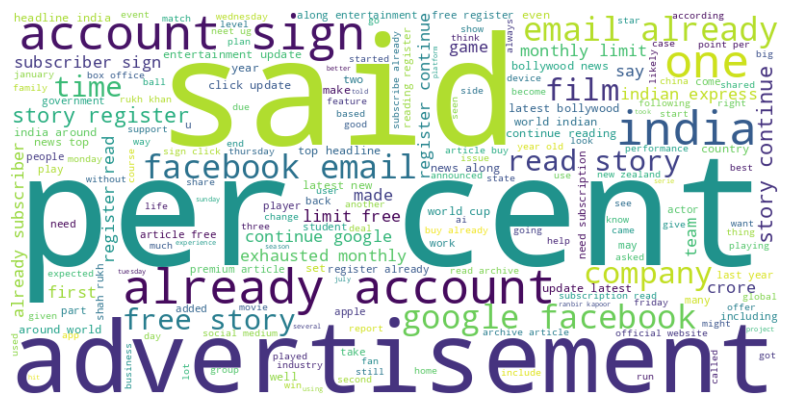

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(df['processed_text']))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
df_subset = df.sample(n=100, random_state=42)  # random_state for reproducibility

# SpaCy-based summarization function
def extract_summary_spacy(text, max_sentences=2):
    doc = nlp(text)
    sentences = [sent.text for sent in doc.sents]
    return " ".join(sentences[:max_sentences]) if len(sentences) > 1 else text

# Apply SpaCy summarization to the subset
df_subset['summary_spacy'] = df_subset['processed_text'].apply(lambda x: extract_summary_spacy(x))

In [ ]:
# Initialize the transformer model (BART)
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Transformer-based summarization function
def extract_summary_transformer(text):
    if len(text.split()) < 10:  # If the text is short, return as is
        return text
    summary = summarizer(text, max_length=10, min_length=2, do_sample=False)
    return summary[0]['summary_text']

# Apply transformer summarization to the subset
df_subset['summary_transformer'] = df_subset['processed_text'].apply(lambda x: extract_summary_transformer(x))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# Save the summarized data to a CSV file
df_subset.to_csv("summarized_news_subset_random.csv", index=False)

# Display the first few rows with summaries
print(df_subset[['processed_text', 'summary_transformer']].head())

                                         processed_text  \
6252  mohammed shami likely miss test england suryak...   
4684  athiya shetty superstitious kl rahul playing c...   
1731  hindustan unilever profit rise june quarter ma...   
4742  vijayakanth tamil nadu loses captain actor pol...   
4521  aamir khan daughter ira khan reacts husband nu...   

                        summary_transformer  
6252             mohammed shami likely miss  
4684            athiya shetty superstitious  
1731   infosys saw volume specific industry  
4742                      vijayakanth tamil  
4521                  Aamir khan's daughter  
